In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import seaborn as sns
## import html
import html


In [14]:
data = pd.read_csv("../data/CRSC.csv", sep=";")
data = data.drop(columns=["Obs"])
data.head(20)

,Y,AGE,NCARTES,PROP,PROF
0,1,49,16,0,5
1,1,57,5,0,6
2,0,37,1,0,5
3,0,44,1,0,2
4,1,60,9,1,7
5,0,58,3,1,8
6,1,44,3,1,5
7,1,54,0,1,3
8,1,43,1,1,5
9,1,37,1,1,5


In [11]:
data.isna().sum()

Obs        0
Y          0
AGE        0
NCARTES    0
PROP       0
PROF       0
dtype: int64

### 1. Etude descriptive des données

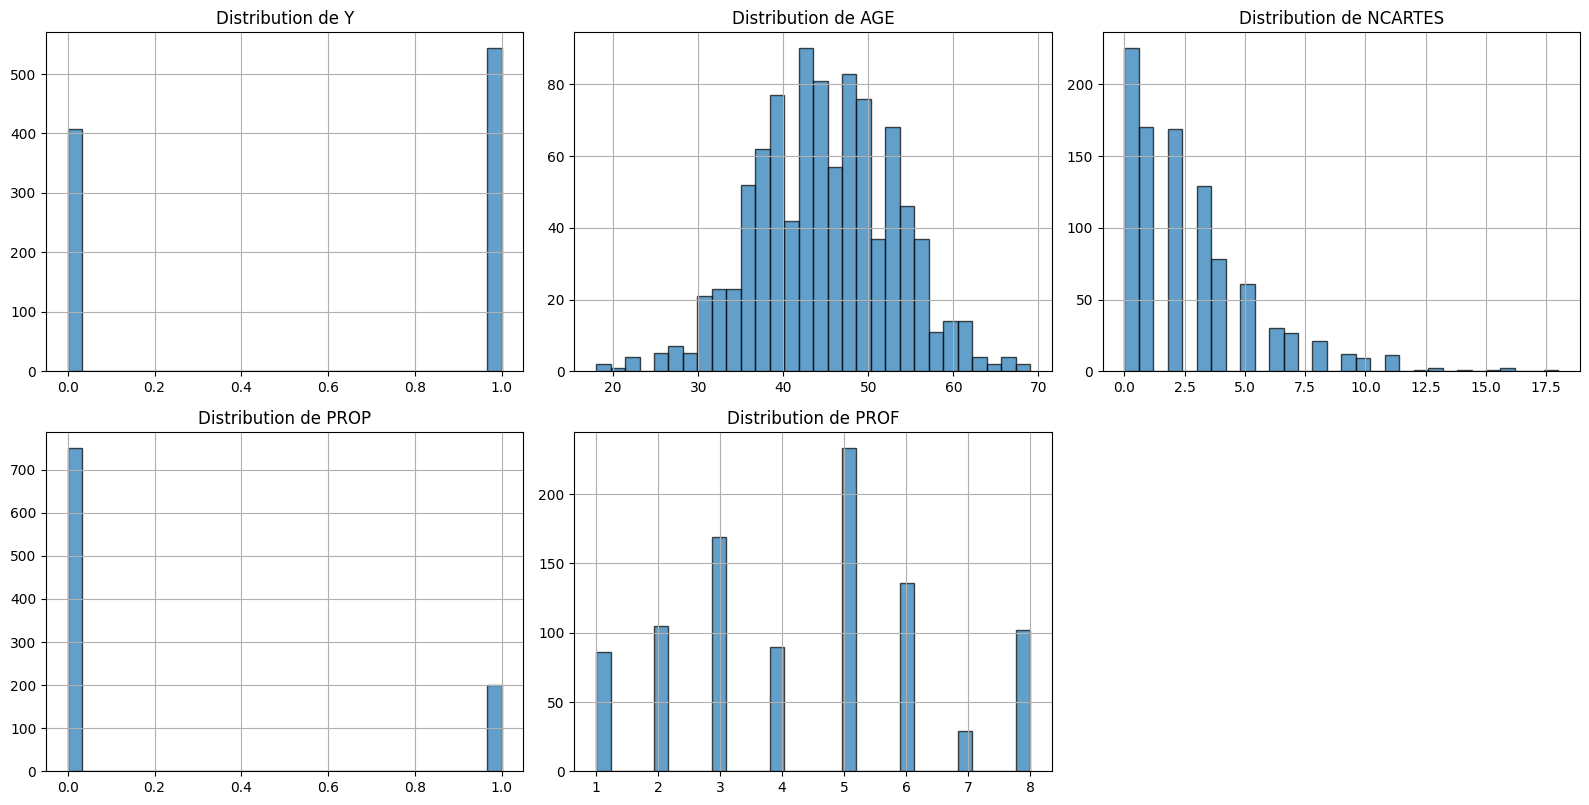

In [15]:
n_cols = 3
n_rows = (len(data) + n_cols - 1) // n_cols

# Histogrammes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*4))
axes = axes.flatten()
for i, var in enumerate(data.columns):
    data[var].hist(ax=axes[i], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution de {var}')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

les graphiques nous montrent :
- les clients bons payeurs sont plus nombreux que les mauvais payeurs
- les clients propriétaires sont largement moins nombreux que les locataires
- la distributiion des noimbres de cartes de crédit suit une loi de puissance
- les clients employés sont plus nombreux parmi les autres catégories professionnelles
- la distribution de l'ege suit à peu près une loi normale.

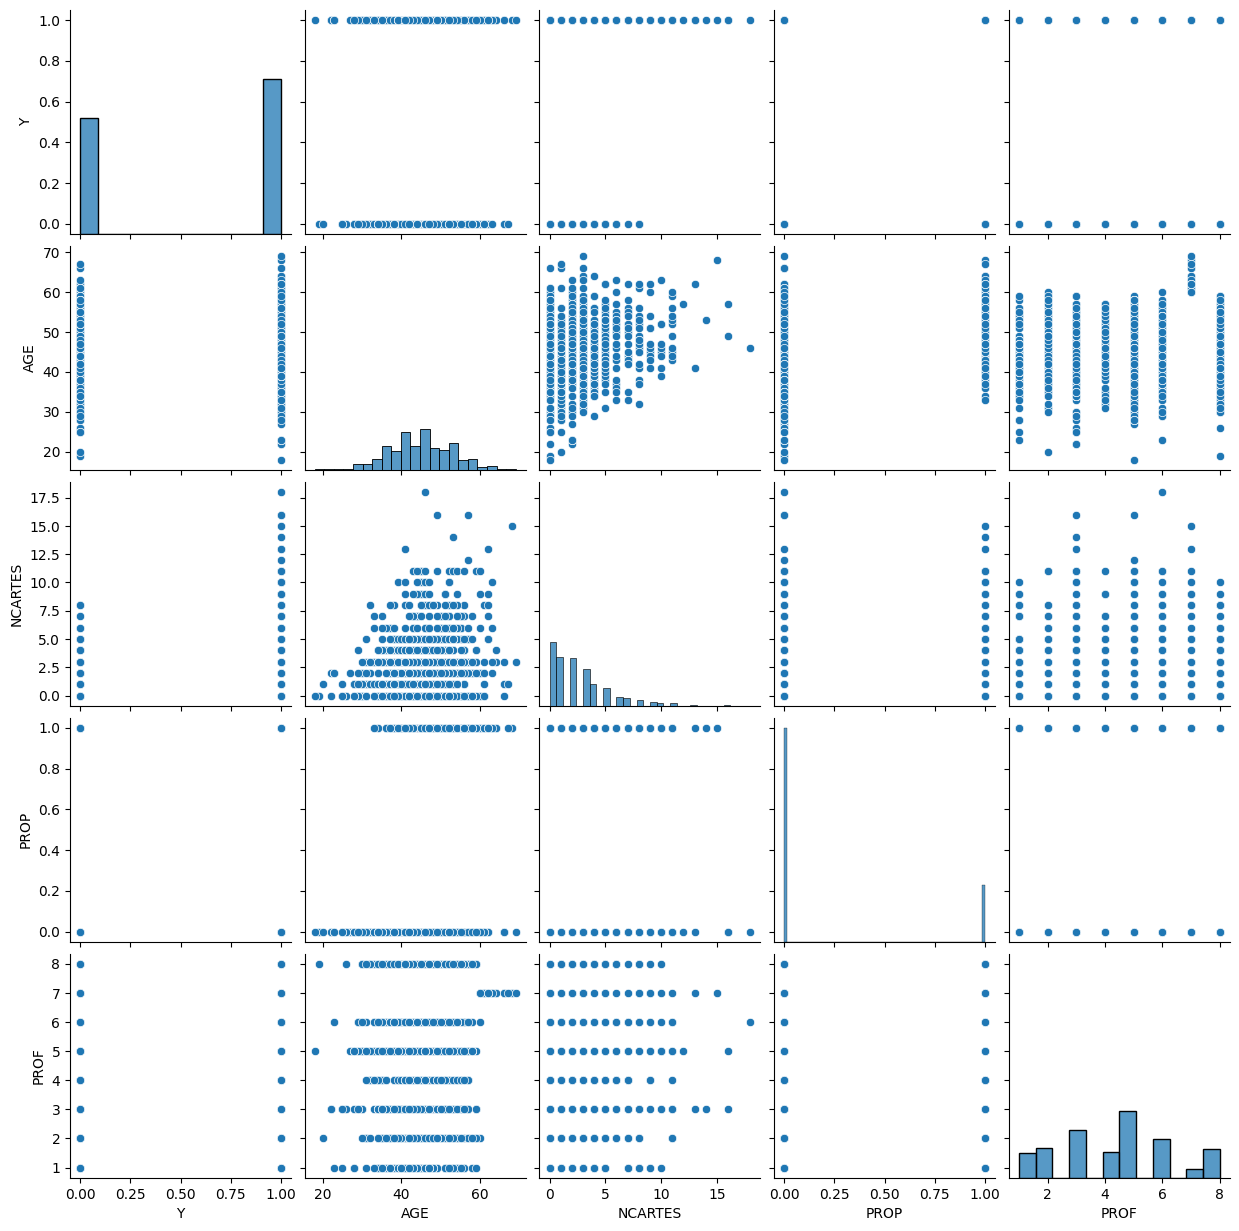

In [19]:
sns.pairplot(data)

D'après les graphiques, on peut souligner que aucune des variables ne semble etre colérée avec la variables cible Y.

/tmp/ipykernel_1924608/1323477812.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_0, data_1], labels=['Y = 1', 'Y = 0'])
/tmp/ipykernel_1924608/1323477812.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_0, data_1], labels=['Y = 1', 'Y = 0'])
/tmp/ipykernel_1924608/1323477812.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_0, data_1], labels=['Y = 1', 'Y = 0'])
/tmp/ipykernel_1924608/1323477812.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support fo

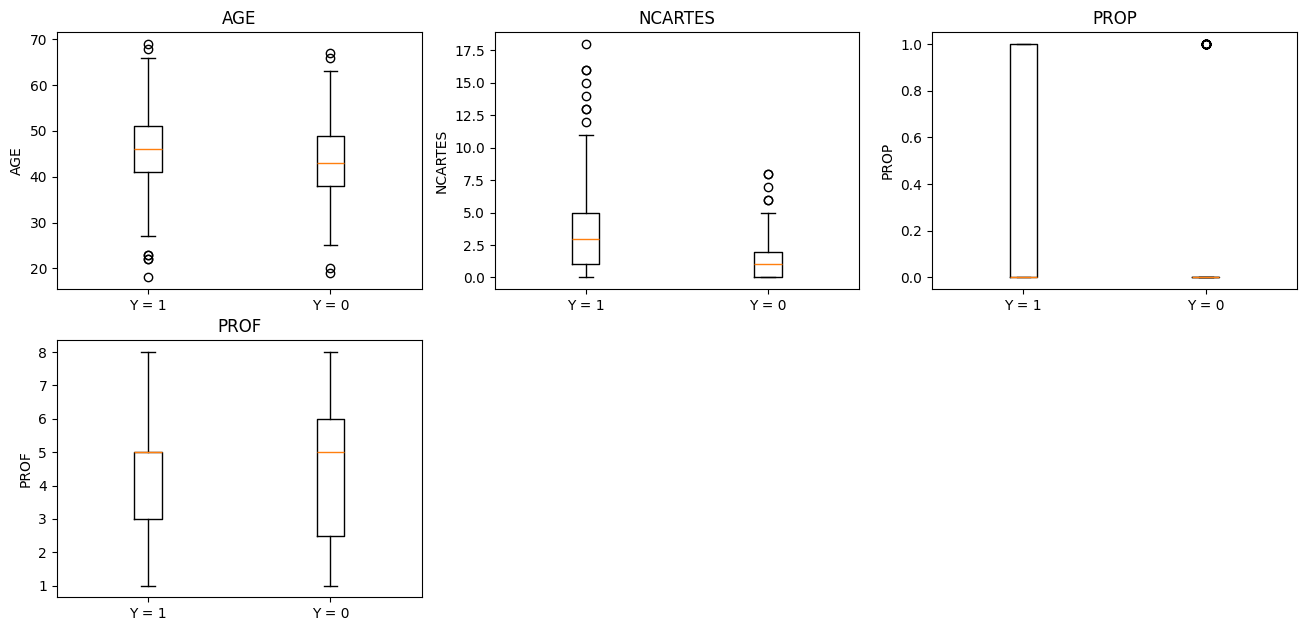

In [21]:
fig, axes = plt.subplots(n_rows, n_cols , figsize=(16, n_rows*4))
axes = axes.flatten()
features = [col for col in data.columns if col != 'Y']
for i, var in enumerate(features):
    data_0 = data[data['Y'] == 1][var].dropna()
    data_1 = data[data['Y'] == 0][var].dropna()
    bp = axes[i].boxplot([data_0, data_1], labels=['Y = 1', 'Y = 0'])
    axes[i].set_title(f'{var}')
    axes[i].set_ylabel(var)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

D'après les graphiques obtenus, on peut noter :
- la répartition des clients bons et mauvais est éuilibrée par rapport à la variable age
- les clients mauvais payeurs en général ne sont pas propriétaires
- en tenant compte des professions, on peut noter que les clients mauvais payeurs sont plus nuombreux mais présentent une moyenne égale à celle des clients bons payeurs
- les mauvais payeurs ont en général un nombre de cartes de crédit moins élevé que les bons payeurs

### 2. ecarts significatifs entre les groupes

#### 2.a en tenant compte de la variable age

In [24]:
from scipy.stats import ttest_ind
cible = 'Y'
var1 = 'AGE'
group1 = data[data[cible] == 1][var1].dropna()
group2 = data[data[cible] == 0][var1].dropna()
t_stat, p_value = ttest_ind(group1, group2)
print(f"t-statistic: {t_stat}, p-value: {p_value}")

t-statistic: 4.97690855464466, p-value: 7.671260615561592e-07


On a un p value de 7.67e-05, ce qui est inférieur au seuil de 0.05, indiquant que la différence d'âge entre les deux groupes de clients (bons et mauvais payeurs) est statistiquement significative. Cela suggère que l'âge pourrait être un facteur important à considérer.

2.b en tenant compte de la variable propriétaire

In [25]:
var2 = 'PROP'
group1 = data[data[cible] == 1][var2].dropna()
group2 = data[data[cible] == 0][var2].dropna()
t_stat, p_value = ttest_ind(group1, group2)
print(f"t-statistic: {t_stat}, p-value: {p_value}")

t-statistic: 11.099050652859825, p-value: 5.373431965854591e-27


On a un p value de 5.373e-27 qui est inférieur au seuil de 0.05, indiquant que la différence entre les deux groupes de clients (bons et mauvais payeurs) en termes de propriété est statistiquement significative. Cela suggère que le statut de propriétaire pourrait être un facteur important à considérer.

### 3. Note

### 4. Modèle logit avec l'age (avec une constante)

In [31]:
## modèle logit
import statsmodels.api as sm
X = data['AGE']
y = data['Y']
X = sm.add_constant(X)
model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.669977
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                  950
Model:                          Logit   Df Residuals:                      948
Method:                           MLE   Df Model:                            1
Date:                Fri, 13 Mar 2026   Pseudo R-squ.:                 0.01887
Time:                        15:57:00   Log-Likelihood:                -636.48
converged:                       True   LL-Null:                       -648.72
Covariance Type:            nonrobust   LLR p-value:                 7.482e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5458      0.382     -4.046      0.000      -2.295      -0.797
AGE            0.0410      0.

In [ ]:
## modèle logit
import statsmodels.api as sm
X = data['PROP']
y = data['Y']
X = sm.add_constant(X)
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.616959
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                  950
Model:                          Logit   Df Residuals:                      948
Method:                           MLE   Df Model:                            1
Date:                Fri, 13 Mar 2026   Pseudo R-squ.:                 0.09651
Time:                        16:14:17   Log-Likelihood:                -586.11
converged:                       True   LL-Null:                       -648.72
Covariance Type:            nonrobust   LLR p-value:                 4.553e-29
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0614      0.073     -0.840      0.401      -0.205       0.082
PROP           2.2099      0.